# Data Analysis Notebook

This notebook reads the train.csv file and creates a dataframe for analysis.

In [3]:
# Installation cell - Run this to install required packages
import subprocess
import sys

def install_package(package):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✅ Successfully installed {package}")
    except Exception as e:
        print(f"❌ Failed to install {package}: {e}")

# Install required packages
packages = ["matplotlib", "seaborn", "openpyxl", "xlrd"]
print("Installing required packages...")

for package in packages:
    try:
        if package == "matplotlib":
            import matplotlib
        elif package == "seaborn":
            import seaborn
        elif package == "openpyxl":
            import openpyxl
        elif package == "xlrd":
            import xlrd
        print(f"✅ {package} is already available")
    except ImportError:
        print(f"Installing {package}...")
        install_package(package)

print("\n🔄 Now restart the kernel and run all cells again:")
print("Kernel -> Restart Kernel, then Run All Cells")


Installing required packages...
✅ matplotlib is already available
✅ seaborn is already available
✅ openpyxl is already available
✅ xlrd is already available

🔄 Now restart the kernel and run all cells again:
Kernel -> Restart Kernel, then Run All Cells


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Try to import plotting libraries (optional for basic analysis)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Set up plotting style
    plt.style.use("default")
    sns.set_palette("husl")
    PLOTTING_AVAILABLE = True
    print("Plotting libraries loaded successfully!")
except ImportError as e:
    print(f"Plotting libraries not available: {e}")
    print("You can still do data analysis without plotting.")
    PLOTTING_AVAILABLE = False

# Display options for better output
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

print("Core libraries loaded successfully!")

/Users/snaseem/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/snaseem/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Plotting libraries loaded successfully!
Core libraries loaded successfully!


In [2]:
# Function to read the data file with error handling
def read_data_file(file_path):
    try:
        print("Attempting to read as CSV...")
        df = pd.read_csv(file_path)
        print("Successfully read as CSV")
        return df
    except Exception as csv_error:
        print(f"CSV reading failed: {csv_error}")
        try:
            print("Attempting to read as Excel...")
            df = pd.read_excel(file_path)
            print("Successfully read as Excel")
            return df
        except Exception as excel_error:
            print(f"Excel reading failed: {excel_error}")
            try:
                print("Attempting to read with openpyxl engine...")
                df = pd.read_excel(file_path, engine="openpyxl")
                print("Successfully read with openpyxl")
                return df
            except Exception as openpyxl_error:
                print(f"Openpyxl reading failed: {openpyxl_error}")
                try:
                    print("Attempting to read with xlrd engine...")
                    df = pd.read_excel(file_path, engine="xlrd")
                    print("Successfully read with xlrd")
                    return df
                except Exception as xlrd_error:
                    print(f"All reading methods failed.")
                    return None

In [3]:
import pandas as pd
import numpy as np

#take csv file and shuffle rows and save as new csv file
df = pd.read_csv("activity_shuffled.csv")
#df = df.sample(frac=1).reset_index(drop=True)
#df.to_csv("activity_shuffled.csv", index=False)
df

,SMILES,ACTIVITY
0,OC(C(C)=O)C,0
1,ON1[C@@H](CCC1)C(=O)O,1
2,C(CCC(=O)O)(=O)O,1
3,[C@@H]1(C[C@H](O)[C@@H](CO)O1)N1C(=O)NC(=O)C(C)=C1,0
4,CCC(O)C(O)=O,0
...,...,...
256,OC1[C@H](O)[C@@H](O)[C@H](O[C@H]2[C@H](O)[C@@H](O)[C@@H](O)[C@H](O2)CO)[C@H](O1)CO,0
257,CCC(C)C(C(O)=O)=O,1
258,N[C@@H](CC(=O)O)C(=O)O,1
259,COC([C@H](O)C)=O,0


In [4]:
df

,SMILES,ACTIVITY
0,OC(C(C)=O)C,0
1,ON1[C@@H](CCC1)C(=O)O,1
2,C(CCC(=O)O)(=O)O,1
3,[C@@H]1(C[C@H](O)[C@@H](CO)O1)N1C(=O)NC(=O)C(C)=C1,0
4,CCC(O)C(O)=O,0
...,...,...
256,OC1[C@H](O)[C@@H](O)[C@H](O[C@H]2[C@H](O)[C@@H](O)[C@@H](O)[C@H](O2)CO)[C@H](O1)CO,0
257,CCC(C)C(C(O)=O)=O,1
258,N[C@@H](CC(=O)O)C(=O)O,1
259,COC([C@H](O)C)=O,0


In [5]:
df = df.sample(frac=1).reset_index(drop=True)
df.to_csv("activity_shuffled.csv", index=False)
df

,SMILES,ACTIVITY
0,NCCC1=CC=C(C=C1)O,0
1,CC(C)CCO,1
2,OC1=CC=C(C(O)CN)C=C1.[H]Cl,0
3,N[C@@H](CCCCN)C(=O)O,1
4,C(=O)O,0
...,...,...
256,CCCCCO,1
257,[C@@H]1([C@H](O)[C@H](O)[C@@H](CO)O1)N1C(=O)NC(=O)C=C1,1
258,O=C(O)[C@H]1N(O)CCC1,1
259,C([C@@H](O)[C@@H](O)[C@H](O)[C@H](O)CO)O,0


In [6]:
## make 2 df files one with 80% of df data and another with 20% of df data

import pandas as pd
import numpy as np

df = pd.read_csv("activity_shuffled.csv")

df_80 = df.sample(frac=0.8)
df_20 = df.drop(df_80.index)

df_80
df_80.to_csv("activity_80.csv", index=False)
df_20.to_csv("activity_20.csv", index=False)

In [8]:
df.describe()

,ACTIVITY
count,261.000000
mean,0.532567
std,0.499897
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [9]:
df_20.describe()


,ACTIVITY
count,52.000000
mean,0.480769
std,0.504505
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [10]:
df_80.describe()

,ACTIVITY
count,209.000000
mean,0.545455
std,0.499125
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [11]:
#drop activity column of df_20 and rename it test_20.csv

import pandas as pd
import numpy as np

df_20 = pd.read_csv("activity_20.csv")
df_20 = df_20.drop(columns=["ACTIVITY"])

#df_20 rename to test_20.csv
df_20.to_csv("test_20.csv", index=False)
df_20

,SMILES
0,NCCC1=CC=C(C=C1)O
1,C(=O)O
2,N[C@@H](CCC(=O)O)C(=O)O
3,N[C@@H](CC(N)=O)C(=O)O
4,P(=O)(O)(O)OC[C@H]([C@H]([C@@H]([C@H](C=O)O)O)O)O
...,...
47,C(C(C)O)O
48,OC1=CC=C(C=C1)C=CC(O)=O
49,CCCCCCCC/C=C\CCCCCCCC(O)=O
50,O[C@H]1[C@H](O)[C@](CO[C@]2(CO[C@]3(CO)O[C@H](CO)[C@@H](O)[C@@H]3O)O[C@H](CO)[C@@H](O)[C@@H]2O)(O[C@@H]4[C@H](O)[C@@H](O)[C@H](O)[C@@H](CO)O4)O[C@@H]1CO


**The END FOR NOW**

In [9]:
# Read the data file
file_path = "train_shuffled_1.csv"
df = read_data_file(file_path)

if df is not None:
    print("\nData loaded successfully!")
    print(f"Dataframe shape: {df.shape}")
    print(f"Number of rows: {df.shape[0]}")
    print(f"Number of columns: {df.shape[1]}")
else:
    print("Failed to load data.")

df

Attempting to read as CSV...
Successfully read as CSV

Data loaded successfully!
Dataframe shape: (126, 2)
Number of rows: 126
Number of columns: 2


,SMILES,ACTIVITY
0,C(C(=C)CC(=O)O)(=O)O,0
1,N[C@@H](CCO)C(=O)O,0
2,OCC(=O)[C@@H](O)[C@H](O)[C@@H](O)CO,0
3,OCC(=O)[C@@H](O)[C@H](O)[C@H](O)CO,1
4,OC=1C=C(C=CC1)CC(=O)O,0
...,...,...
121,N[C@@H]([C@H](O)C)C(=O)O,0
122,O=C[C@H](O)[C@@H](O)[C@H](O)[C@H](O)C(=O)O,1
123,N[C@@H](CCC(N)=O)C(=O)O,1
124,C(C)(CC)N,0


In [12]:
# Basic statistics for numerical columns
if df is not None:
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    if len(numerical_cols) > 0:
        print("\n=== NUMERICAL COLUMNS STATISTICS ===")
        print(df[numerical_cols].describe())
    else:
        print("No numerical columns found.")
    
    categorical_cols = df.select_dtypes(include=["object"]).columns
    if len(categorical_cols) > 0:
        print("\n=== CATEGORICAL COLUMNS ===")
        for col in categorical_cols:
            print(f"\n{col}:")
            print(f"Unique values: {df[col].nunique()}")
            print(df[col].value_counts().head())


=== NUMERICAL COLUMNS STATISTICS ===
         ACTIVITY
count  261.000000
mean     0.532567
std      0.499897
min      0.000000
25%      0.000000
50%      1.000000
75%      1.000000
max      1.000000

=== CATEGORICAL COLUMNS ===

SMILES:
Unique values: 261
OC(C(C)=O)C                  1
N[C@@H](CCCNC(N)=N)C(O)=O    1
C(CC)(=O)O                   1
O=C1NC=CC(N)=N1              1
N[C@@H](CC(N)=O)C(=O)O       1
Name: SMILES, dtype: int64


In [20]:
# Display basic information about the dataframe
if df is not None:
    print("\n=== DATAFRAME INFO ===")
    print(df.info())
    print("\n=== FIRST 5 ROWS ===")
    print(df.head())
    print("\n=== COLUMN NAMES ===")
    print(list(df.columns))


=== DATAFRAME INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   SMILES    271 non-null    object
 1   ACTIVITY  272 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.4+ KB
None

=== FIRST 5 ROWS ===
                      SMILES  ACTIVITY
0               CCC(O)C(O)=O         0
1                 C(CC)(=O)O         1
2  N[C@@H](CCCNC(N)=N)C(=O)O         1
3       NC1=C2C(N=CN2)=NC=N1         1
4    N[C@@H](CCC(=O)O)C(=O)O         1

=== COLUMN NAMES ===
['SMILES', 'ACTIVITY']


In [21]:
# Basic statistics for numerical columns
if df is not None:
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    if len(numerical_cols) > 0:
        print("\n=== NUMERICAL COLUMNS STATISTICS ===")
        print(df[numerical_cols].describe())
    else:
        print("No numerical columns found.")
    
    categorical_cols = df.select_dtypes(include=["object"]).columns
    if len(categorical_cols) > 0:
        print("\n=== CATEGORICAL COLUMNS ===")
        for col in categorical_cols:
            print(f"\n{col}:")
            print(f"Unique values: {df[col].nunique()}")
            print(df[col].value_counts().head())


=== NUMERICAL COLUMNS STATISTICS ===
         ACTIVITY
count  272.000000
mean     0.544118
std      0.498968
min      0.000000
25%      0.000000
50%      1.000000
75%      1.000000
max      1.000000

=== CATEGORICAL COLUMNS ===

SMILES:
Unique values: 261
SMILES
NCCCCN                     2
O=C1CCCCN1                 2
O=C(O)CCCN                 2
NCCO                       2
N[C@@H](CCC(O)=O)C(O)=O    2
Name: count, dtype: int64


In [7]:
# Check for missing values
if df is not None:
    missing_values = df.isnull().sum()
    if missing_values.sum() > 0:
        print("\n=== MISSING VALUES ===")
        print(missing_values[missing_values > 0])
    else:
        print("No missing values found.")

No missing values found.


In [8]:
# Save the dataframe for future use
if df is not None:
    df.to_pickle("dataframe.pkl")
    df.to_csv("cleaned_data.csv", index=False)
    print("Dataframe saved for future use.")
    print(f"Dataframe ready for analysis with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataframe saved for future use.
Dataframe ready for analysis with 126 rows and 2 columns.


✅ Plotting libraries are working!


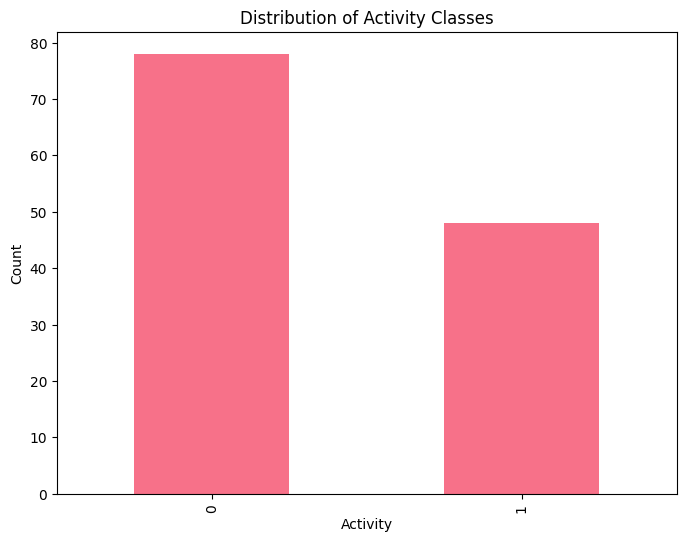

In [9]:
# Test the plotting libraries and install if needed
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("✅ Plotting libraries are working!")
    
    # If we have data, let's create a simple plot
    if 'df' in locals() and df is not None:
        plt.figure(figsize=(8, 6))
        df['ACTIVITY'].value_counts().plot(kind='bar')
        plt.title('Distribution of Activity Classes')
        plt.xlabel('Activity')
        plt.ylabel('Count')
        plt.show()
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("If you're running this in Jupyter, try restarting the kernel:")
    print("Kernel -> Restart Kernel")
    print("Or install packages by running this in a cell:")
    print("!pip install matplotlib seaborn")


In [10]:
# Install scikit-learn if not available
try:
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestClassifier
    print("✅ Scikit-learn is available!")
except ImportError:
    print("❌ Scikit-learn not found. Installing...")
    %pip install scikit-learn
    print("✅ Please restart kernel and run this cell again")

# Shuffle the rows and data so that the data is not biased
df = df.sample(frac=1).reset_index(drop=True)

# Split the data into training and testing sets
# Note: Column name is 'ACTIVITY' (uppercase), not 'Activity'
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('ACTIVITY', axis=1), 
    df['ACTIVITY'], 
    test_size=0.2, 
    random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
print("✅ Model initialized successfully!")

✅ Scikit-learn is available!
Training set size: (100, 1)
Testing set size: (26, 1)
✅ Model initialized successfully!


In [14]:
print(X_test.shape)

(26, 1)


In [ ]:
#

Installing required packages...
✅ matplotlib is already available
✅ seaborn is already available
✅ openpyxl is already available
✅ xlrd is already available

🔄 Now restart the kernel and run all cells again:
Kernel -> Restart Kernel, then Run All Cells


In [14]:
# Alternative: Direct installation (run this cell if the above doesn't work)
# This installs packages directly into the current Jupyter kernel

%pip install matplotlib seaborn openpyxl xlrd scikit-learn

print("✅ Package installation completed!")
print("🔄 Please restart the kernel now: Kernel -> Restart Kernel")
print("Then run all cells again from the beginning.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 4.0 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.7/20.7 MB 3.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.
✅ Package installation completed!
🔄 Please restart the kernel now: Kernel -> Restart Kernel
Then run all cells again from the beginning.
